In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
plt.rcParams["xtick.direction"] = "in"
plt.rcParams["ytick.direction"] = "in"
plt.rc("font", family="STIXGeneral", size=18)
plt.rcParams["mathtext.fontset"] = "stix"
plt.rcParams['figure.figsize'] = (2*10/3, 4)
plt.rcParams["legend.frameon"] = False


plt.rcParams["xtick.major.size"] = 5
plt.rcParams["ytick.major.size"] = 5
plt.rcParams["ytick.minor.visible"] = True
plt.rcParams["xtick.minor.visible"] = True
plt.rcParams["xtick.top"] = True
plt.rcParams["ytick.right"] = True
plt.rcParams["lines.linewidth"] = 2

In [3]:
boxsize = 205

In [4]:
seed = 0

In [69]:
nhalos = 1122731 # total number of halos in tng 300

In [25]:
nhalos = 500000 # of order of number of halos in tng300

Don't allow halos to be within r=distance of each other

Create random sample of nhalo 3d-coordinates

In [26]:
from sklearn.neighbors import KDTree
rng = np.random.RandomState(seed)
X = rng.random_sample((nhalos, 3))*boxsize  # nhalos in 3 dimensions

Check how uniform it is by computing the correlation function

In [27]:
pixlen = 0.09

In [28]:
from Corrfunc.theory import xi
rmin = 0.1
rmax = 10.0
nbins = 100
bins = np.logspace(np.log10(rmin), np.log10(rmax), nbins + 1)
results = xi(boxsize, 2, bins , X[:,0],X[:,1],X[:,2], 
             weights=None,output_ravg=True)

(-1.1, 1.1)

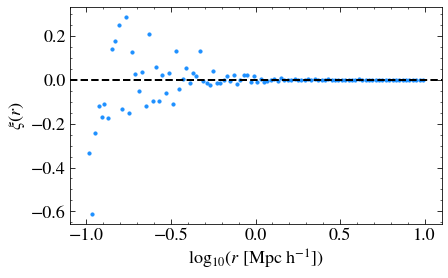

In [29]:
plt.hlines(0, xmin=-1.1, xmax=1.1, color="k", linestyle="dashed")
plt.scatter(np.log10(results["ravg"]), results["xi"], s=10, color="DodgerBlue")
plt.xlabel("log$_{10}$($r$ [Mpc h$^{-1}$])")
plt.ylabel(r"$\xi(r)$")
plt.xlim(-1.1, 1.1)
#plt.savefig("../figures/correlation_function_random.pdf", format="pdf", bbox_inches="tight")

Find indices where the halos are less than r=distance of each other

In [30]:
R = 0.3

In [31]:
distance = 2*R
tree = KDTree(X, leaf_size=2)
ind = tree.query_radius(X, r=distance)

`ind` returns an array of arrays. In each array is the index of the halo and any other halos that are within r = distance. If the array only has one element then it means there are no halos within `r = distance`.

Remove halos which are less than r=distance within each other

In [32]:
mask = np.array([True]*len(X))

for i, indices in enumerate(ind):
    #print(indices)
    if (len(indices) > 1): # if true, then there exist halos within r = distance
        mask1 = indices > i # get all halos with index after i
        #if np.any(mask1): # if any of them are true
        if np.sum(mask1)>0: # if there exist any indices greater than i (which are within r of halo i) - the ones with lower indices have already been removed
            mask[i] = False # remove halo at index i

In [33]:
nhalos_remaining = np.sum(mask)
nhalos_removed = np.sum(~mask)
print(nhalos_remaining)
print(nhalos_removed)

487072
12928


In [65]:
frac_removed = nhalos_removed/nhalos
new_total1 = nhalos+nhalos_removed
print("Plus Removed:", new_total1)
addition = int(new_total1*frac_removed)+3640
print("addition:", addition)
new_total2 = nhalos + addition
print("Original Nhalo:", nhalos)
#print("new_total1:", new_total1)
print("new_total2:", new_total2)

Plus Removed: 1050572
addition: 56769
Original Nhalo: 1000000
new_total2: 1056769


Put the removed halos back in the box randomly in order to keep the total number of halos the same

In [66]:
rng = np.random.RandomState(seed+1) # reset seed
X2 = rng.random_sample((new_total2, 3))*boxsize  # nhalos in 3 dimensions
tree = KDTree(X2, leaf_size=2)
ind2 = tree.query_radius(X2, r=distance)

In [67]:
mask2 = np.array([True]*len(X2))
for i, indices in enumerate(ind2):
    #print(indices)
    if (len(indices) > 1): # then there exist halos within r = distance
        mask1 = indices > i
        if np.any(mask1):
            mask2[i] = False # remove halos which are within r = distance of another halo

In [68]:
nhalos_remaining2 = np.sum(mask2)
nhalos_removed2 = np.sum(~mask2)
print("Target nhalos:", nhalos)
print("New total initial nhalos:", new_total2)
print("New halos remaining:", nhalos_remaining2)
print(nhalos_removed2)

print("Difference to target:", nhalos-nhalos_remaining2)

Target nhalos: 1000000
New total initial nhalos: 1056769
New halos remaining: 1000000
56769
Difference to target: 0


Check correlation function of this random distribution with halo exclusion

In [18]:
rmin = 0.1
rmax = 10.0
nbins = 100
bins = np.logspace(np.log10(rmin), np.log10(rmax), nbins + 1)
results2 = xi(boxsize, 2, bins , X[:,0][mask],X[:,1][mask],X[:,2][mask], 
             weights=None,output_ravg=True)

In [19]:
X_exclusion = X[mask]

In [20]:
bin_cents = (bins[:-1]+bins[1:])/2

In [21]:
ravg2 = np.where(results2["ravg"]==0, bin_cents, results2["ravg"])


(-1.1, 0.1)

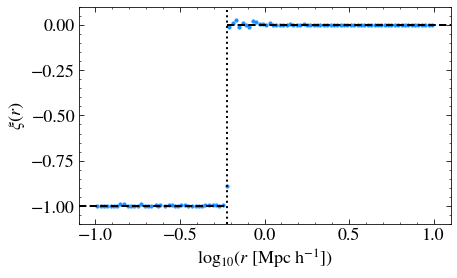

In [22]:
plt.hlines(-1, xmin=-1.1, xmax=np.log10(0.6), color="k", linestyle="dashed")
plt.hlines(0, xmin=np.log10(0.6), xmax=1.1, color="k", linestyle="dashed")

plt.vlines(np.log10(0.6), ymin=-1.1, ymax=0.1, color="k", linestyle="dotted")
plt.scatter(np.log10(ravg2), results2["xi"], s=10, color="DodgerBlue")
plt.xlabel("log$_{10}$($r$ [Mpc h$^{-1}$])")
plt.ylabel(r"$\xi$($r$)")
plt.xlim(-1.1, 1.1)
plt.ylim(-1.1, 0.1)
#plt.savefig("../figures/correlation_function_2R=0.6.pdf", format="pdf", bbox_inches="tight")

In [23]:
x_cent, y_cent, z_cent = X_exclusion[:,0], X_exclusion[:,1], X_exclusion[:,2]

In [24]:

with open(f"random_halo_exclusion_2R={distance}_no_replacement.txt", "w") as f:
    print("# logM[Msun/h] x[Mpc/h] y[Mpc/h] z[Mpc/h] SFR[Msun/yr]", file=f)

    for i in range(len(x_cent)):
        print(1, x_cent[i],y_cent[i],z_cent[i], 1, file = f)

Add satellites

In [136]:
nsat = 15 # nsats per halo

In [137]:
# For simplicity satellite distribution in each halo will be the same
rng3 = np.random.RandomState(seed+2) # reset seed
theta = 2*np.pi*rng3.random_sample(nsat)
phi = np.pi * rng3.random_sample(nsat)
r = (rng3.random_sample(nsat)*R**3)**(1/3)

In [138]:
xsat = r * np.sin(phi) * np.cos(theta)
ysat = r * np.sin(phi) * np.sin(theta)
zsat = r * np.cos(phi)

In [139]:
from mpl_toolkits.mplot3d import Axes3D

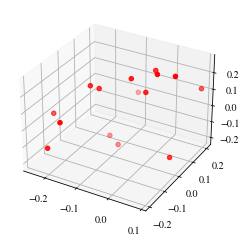

In [140]:
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

# Plot the points
ax.scatter(xsat, ysat, zsat, c='r', marker='o')

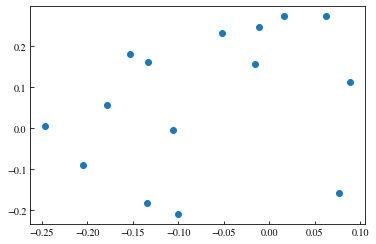

In [141]:
plt.scatter(xsat,zsat)

In [169]:
x_w_sat = x_cent[:, np.newaxis] + np.concatenate(([0], xsat))
x_pos = x_w_sat.flatten()

y_w_sat = y_cent[:, np.newaxis] + np.concatenate(([0], ysat))
y_pos = y_w_sat.flatten()

z_w_sat = z_cent[:, np.newaxis] + np.concatenate(([0], zsat))
z_pos = z_w_sat.flatten()

In [176]:
mask = (x_pos < 10) & (y_pos < 10) & (z_pos < 2)

In [ ]:
plt.scatter(x_pos[mask], y_pos[mask], marker=",")

In [170]:
rmin = 0.1
rmax = 10.0
nbins = 100
bins = np.logspace(np.log10(rmin), np.log10(rmax), nbins + 1)
results2 = xi(boxsize, 2, bins , x_pos,y_pos,z_pos, 
             weights=None,output_ravg=True)

In [171]:
ravg2 = np.where(results2["ravg"]==0, bin_cents, results2["ravg"])


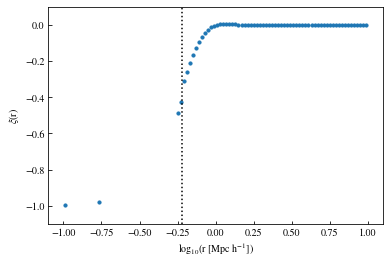

In [173]:
#plt.hlines(-1, xmin=-1.1, xmax=np.log10(0.6), color="k", linestyle="dashed")
#plt.hlines(0, xmin=np.log10(0.6), xmax=1.1, color="k", linestyle="dashed")

plt.vlines(np.log10(0.6), ymin=-1.1, ymax=0.1, color="k", linestyle="dotted")
plt.scatter(np.log10(ravg2), results2["xi"], s=10)
plt.xlabel("log$_{10}$(r [Mpc h$^{-1}$])")
plt.ylabel(r"$\xi$(r)")
plt.xlim(-1.1, 1.1)
plt.ylim(-1.1, 0.1)
#plt.savefig("../figures2/correlation_function_2R=0.6_nsat15.pdf", format="pdf", bbox_inches="tight")

In [175]:

with open(f"random_halo_exclusion_2R={distance}_nsat15.txt", "w") as f:
    print("# logM[Msun/h] x[Mpc/h] y[Mpc/h] z[Mpc/h] SFR[Msun/yr]", file=f)

    for i in range(len(x_pos)):
        print(1, x_pos[i],y_pos[i],z_pos[i], 1, file = f)

In [89]:

with open(f"random_seed0.txt", "w") as f:
    print("# logM[Msun/h] x[Mpc/h] y[Mpc/h] z[Mpc/h] SFR[Msun/yr]", file=f)

    for i in range(len(X)):
        print(1, X[:,0][i],X[:,1][i],X[:,2][i], 1, file = f)

In [15]:
from nbodykit.source.catalog import ArrayCatalog
from nbodykit.lab import *

In [16]:
Nmesh = boxsize/0.01
print(Nmesh)

1000.0


In [42]:
pos.shape

(2070, 3)

In [104]:
len(pos)

2028

In [17]:
halocat = np.empty(len(pos), dtype=[("Position", ("f8", 3))])
halocat["Position"] = np.array(pos)

In [18]:

arraycat = ArrayCatalog(halocat)
mesh = arraycat.to_mesh(resampler="tsc", BoxSize=boxsize, Nmesh=Nmesh, compensated=True)

In [19]:
kmin = 2 * np.pi / boxsize
print(kmin)

0.6283185307179586


In [46]:
r1 = 0.5
k1 = 2*np.pi/r1
print(k1)
print(np.log10(k1))
k1 = 1/r1
print(k1)
print(np.log10(k1))

12.566370614359172
1.0992098640220962
2.0
0.3010299956639812


In [ ]:
r = FFTPower(mesh, mode='1d', dk=kmin, kmin=kmin)
Pk = r.power

In [85]:
shotnoise = Pk.attrs["shotnoise"]
print(shotnoise)

0.10195758564437195


In [52]:
print(Pk["power"]-shotnoise)

[-2.35455323e-01+0.j -2.69409699e-01+0.j -3.13491132e-01+0.j
 -2.62127926e-01+0.j -3.08910849e-01+0.j -2.65446944e-01+0.j
 -2.55709086e-01+0.j -2.27020607e-01+0.j -1.94930328e-01+0.j
 -1.69056168e-01+0.j -1.04502105e-01+0.j -6.83078953e-02+0.j
 -2.43000900e-02+0.j -1.41331444e-02+0.j  2.47998966e-02+0.j
  2.50206082e-02+0.j  4.18909064e-02+0.j  3.55203177e-02+0.j
  7.33570056e-02+0.j  4.00791386e-02+0.j  3.05140265e-02+0.j
  1.97599139e-02+0.j  5.37443024e-03+0.j -2.05349600e-04+0.j
 -8.02147611e-03+0.j -2.41684058e-02+0.j -2.08143786e-02+0.j
 -1.88375143e-02+0.j -2.21525247e-02+0.j -8.90168064e-03+0.j
 -1.07223113e-02+0.j  1.10621431e-03+0.j -5.15921107e-03+0.j
  1.27215959e-03+0.j  4.61809664e-03+0.j  9.01671223e-03+0.j
 -4.99119370e-05+0.j  2.64058946e-03+0.j  1.34842255e-02+0.j
  4.87468615e-03+0.j  1.58476028e-02+0.j  3.60891337e-03+0.j
  3.42004612e-03+0.j  1.36234578e-03+0.j  5.37791008e-03+0.j
 -4.79949924e-03+0.j -8.27562713e-03+0.j -6.99425263e-03+0.j
 -1.06334055e-02+0.j -6.

In [64]:
test = kcoef*(Pk["power"]-shotnoise)
print(test[:10])

[-0.00840807+0.j -0.04679632+0.j -0.15669314+0.j -0.28643924+0.j
 -0.63433919+0.j -0.89485714+0.j -1.32701367+0.j -1.72932211+0.j
 -2.08169562+0.j -2.4379244 +0.j]


In [65]:
print(np.log10(test[:10]))

[-2.07530365+1.36437635j -1.32978827+1.36437635j -0.80495002+1.36437635j
 -0.54296748+1.36437635j -0.19767845+1.36437635j -0.04824629+1.36437635j
  0.1228754 +1.36437635j  0.23787589+1.36437635j  0.31841723+1.36437635j
  0.38702023+1.36437635j]


In [63]:
print(np.log10(Pk["k"])[:10])
print(np.log10(kcoef[:10]*(Pk["power"][:10]-shotnoise)))

[-0.05062747  0.17837608  0.33138482  0.44461632  0.53593937  0.60770191
  0.67015299  0.72571345  0.77462252  0.81810632]
[-2.07530365+1.36437635j -1.32978827+1.36437635j -0.80495002+1.36437635j
 -0.54296748+1.36437635j -0.19767845+1.36437635j -0.04824629+1.36437635j
  0.1228754 +1.36437635j  0.23787589+1.36437635j  0.31841723+1.36437635j
  0.38702023+1.36437635j]


/cosma/local/Python/3.6.5/lib/python3.6/site-packages/numpy/core/_asarray.py:136: ComplexWarning: Casting complex values to real discards the imaginary part
  return array(a, dtype, copy=False, order=order, subok=True)


Text(0, 0.5, '$\\rm log_{10}(k^3 \\ P(k) / 2\\pi^2$) [Jy$^2$ sr$^{-2}]$')

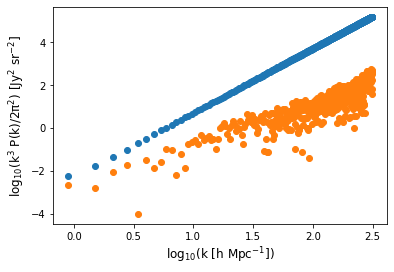

In [88]:
fontsize=12
kcoef = Pk["k"]**3 / (2*np.pi**2)
plt.scatter(np.log10(Pk["k"]), np.log10(kcoef*Pk["power"]))
plt.scatter(np.log10(Pk["k"]), np.log10(kcoef*(Pk["power"]-shotnoise)))
plt.xlabel("log$_{10}$(k [h Mpc$^{-1}$])", fontsize=fontsize)
plt.ylabel(r"$\rm log_{10}(k^3 \ P(k) / 2\pi^2$) [Jy$^2$ sr$^{-2}]$", fontsize=fontsize)
#plt.vlines(1.1, ymin=-2, ymax=3)
#plt.vlines(0.3, ymin=-2, ymax=3)

/cosma/local/Python/3.6.5/lib/python3.6/site-packages/numpy/core/_asarray.py:136: ComplexWarning: Casting complex values to real discards the imaginary part
  return array(a, dtype, copy=False, order=order, subok=True)


(-100.0, 142.27501357690483)

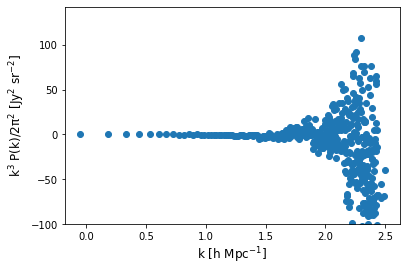

In [95]:
fontsize=12
kcoef = Pk["k"]**3 / (2*np.pi**2)
#plt.scatter(np.log10(Pk["k"]), np.log10(kcoef*Pk["power"]))
plt.scatter(np.log10(Pk["k"]), kcoef*(Pk["power"]-shotnoise))
plt.xlabel("k [h Mpc$^{-1}$]", fontsize=fontsize)
plt.ylabel(r"$\rm k^3 \ P(k) / 2\pi^2$ [Jy$^2$ sr$^{-2}]$", fontsize=fontsize)
#plt.vlines(1.1, ymin=-2, ymax=3)
#plt.vlines(0.3, ymin=-2, ymax=3)
plt.ylim(-100)

/cosma/local/Python/3.6.5/lib/python3.6/site-packages/numpy/core/_asarray.py:136: ComplexWarning: Casting complex values to real discards the imaginary part
  return array(a, dtype, copy=False, order=order, subok=True)


Text(0, 0.5, 'P(k) [Jy$^2$ sr$^{-2}]$')

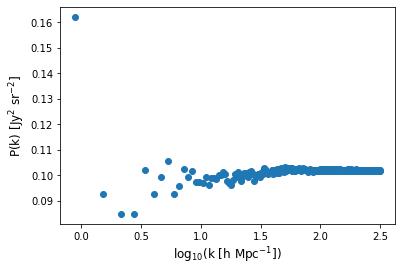

In [90]:
plt.scatter(np.log10(Pk["k"]), Pk["power"])
#plt.scatter(np.log10(Pk["k"]), Pk["power"]-shotnoise)
plt.xlabel("log$_{10}$(k [h Mpc$^{-1}$])", fontsize=fontsize)
plt.ylabel(r"P(k) [Jy$^2$ sr$^{-2}]$", fontsize=fontsize)
#plt.vlines(1.1, ymin=0.8, ymax=1.5)
#plt.vlines(0.3, ymin=0.8, ymax=1.5)

/cosma/local/Python/3.6.5/lib/python3.6/site-packages/numpy/core/_asarray.py:136: ComplexWarning: Casting complex values to real discards the imaginary part
  return array(a, dtype, copy=False, order=order, subok=True)


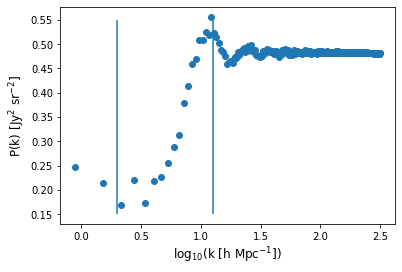

In [50]:
plt.scatter(np.log10(Pk["k"]), Pk["power"])
#plt.scatter(np.log10(Pk["k"]), Pk["power"]-shotnoise)
plt.xlabel("log$_{10}$(k [h Mpc$^{-1}$])", fontsize=fontsize)
plt.ylabel(r"P(k) [Jy$^2$ sr$^{-2}]$", fontsize=fontsize)
plt.vlines(1.1, ymin=0.15, ymax=0.55)
plt.vlines(0.3, ymin=0.15, ymax=0.55)

/cosma/local/Python/3.6.5/lib/python3.6/site-packages/numpy/core/_asarray.py:136: ComplexWarning: Casting complex values to real discards the imaginary part
  return array(a, dtype, copy=False, order=order, subok=True)


Text(0, 0.5, 'P(k) [Jy$^2$ sr$^{-2}]$')

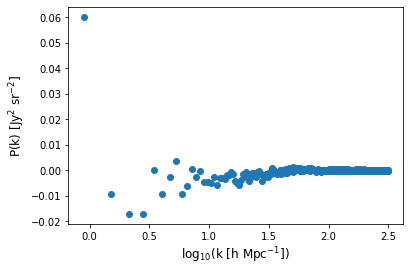

In [92]:
plt.scatter(np.log10(Pk["k"]), Pk["power"]-shotnoise)
plt.xlabel("log$_{10}$(k [h Mpc$^{-1}$])", fontsize=fontsize)
plt.ylabel(r"P(k) [Jy$^2$ sr$^{-2}]$", fontsize=fontsize)
#plt.vlines(1.1, ymin=-0.35, ymax=0.1)
#plt.vlines(0.3, ymin=-0.35, ymax=0.1)